In [1]:
# Gate: load the two global SHAP tables and show their columns, so the
# plotting cell can be pointed at the right ones.
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
T = ROOT / "outputs" / "tables"

m1 = pd.read_csv(T / "08_m1_global_shap.csv")
m2 = pd.read_csv(T / "08_m2_global_shap.csv")

print("M1 columns:", list(m1.columns), "| rows:", len(m1))
print("M2 columns:", list(m2.columns), "| rows:", len(m2))
print(m1.head(3))

M1 columns: ['Unnamed: 0', 'mean_abs_shap'] | rows: 10
M2 columns: ['Unnamed: 0', 'rank', 'mean_abs_shap', 'family', 'share_%'] | rows: 26
       Unnamed: 0  mean_abs_shap
0  Payment Format       1.245876
1       From Bank       1.003990
2     Amount Paid       0.514667


graph 52.81% | confounded 32.17% of total mass
saved: c:\Fintech-Project\graph_AML_pipeline\outputs\figures\13_shap_displacement.png


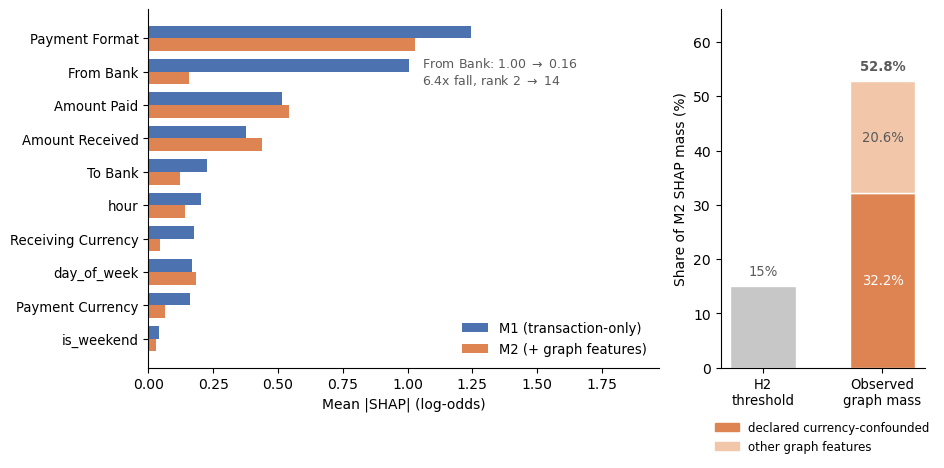

In [2]:
# Figure 1: (A) the ten features both models share, M1 vs M2.
# (B) H2 verdict - observed graph mass against the registered 15% threshold,
# split by the currency-confound declaration.
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

FEAT_COL, VAL_COL = "Unnamed: 0", "mean_abs_shap"
BLUE, ORANGE, PALE, GREY, DARK = "#4C72B0", "#DD8452", "#F2C6A8", "#C7C7C7", "#5A5A5A"

s1  = m1.set_index(FEAT_COL)[VAL_COL]
s2  = m2.set_index(FEAT_COL)[VAL_COL]
fam = m2.set_index(FEAT_COL)["family"]

is_graph = fam.str.startswith("graph_")
is_conf  = is_graph & s2.index.str.endswith(
    ("in_weighted", "out_weighted", "net_flow", "pagerank"))

total     = s2.sum()
graph_pct = 100 * s2[is_graph].sum() / total
conf_pct  = 100 * s2[is_conf].sum()  / total

# gates: the figure must reproduce the registered / verified numbers
assert is_graph.sum() == 16 and is_conf.sum() == 8
assert abs(graph_pct - 52.81) < 0.05, f"graph {graph_pct:.2f}"
assert abs(conf_pct  - 32.17) < 0.05, f"conf {conf_pct:.2f}"
print(f"graph {graph_pct:.2f}% | confounded {conf_pct:.2f}% of total mass")

fig, (axA, axB) = plt.subplots(
    1, 2, figsize=(9.6, 4.8), gridspec_kw={"width_ratios": [2.5, 1.0]})

# --- Panel A ------------------------------------------------------------
shared = list(s1.sort_values().index)      # ascending -> largest at top
y, h = np.arange(len(shared)), 0.38
axA.barh(y + h/2, s1.reindex(shared).values, height=h, color=BLUE,
         label="M1 (transaction-only)")
axA.barh(y - h/2, s2.reindex(shared).values, height=h, color=ORANGE,
         label="M2 (+ graph features)")
axA.set_yticks(y); axA.set_yticklabels(shared, fontsize=9.5)
axA.set_xlim(0, s1.max() * 1.58)
axA.set_xlabel("Mean |SHAP| (log-odds)", fontsize=10)
axA.spines[["top", "right"]].set_visible(False)
axA.legend(frameon=False, fontsize=9.5, loc="lower right")

fb = shared.index("From Bank")
axA.text(s1["From Bank"] + 0.05, fb,
         f"From Bank: {s1['From Bank']:.2f} $\\rightarrow$ {s2['From Bank']:.2f}\n"
         "6.4x fall, rank 2 $\\rightarrow$ 14",
         fontsize=9, va="center", color=DARK)

# --- Panel B ------------------------------------------------------------
axB.bar(0, 15, width=0.55, color=GREY, edgecolor="white")
axB.bar(1, conf_pct, width=0.55, color=ORANGE, edgecolor="white")
axB.bar(1, graph_pct - conf_pct, bottom=conf_pct, width=0.55,
        color=PALE, edgecolor="white")

axB.text(0, 17, "15%", ha="center", fontsize=9.5, color=DARK)
axB.text(1, conf_pct/2, f"{conf_pct:.1f}%", ha="center", va="center",
         fontsize=9.5, color="white")
axB.text(1, conf_pct + (graph_pct - conf_pct)/2, f"{graph_pct - conf_pct:.1f}%",
         ha="center", va="center", fontsize=9.5, color=DARK)
axB.text(1, graph_pct + 2, f"{graph_pct:.1f}%", ha="center", fontsize=9.5,
         color=DARK, fontweight="bold")

axB.set_xticks([0, 1])
axB.set_xticklabels(["H2\nthreshold", "Observed\ngraph mass"], fontsize=9.5)
axB.set_ylim(0, 66)
axB.set_ylabel("Share of M2 SHAP mass (%)", fontsize=10)
axB.spines[["top", "right"]].set_visible(False)
axB.legend(handles=[Patch(color=ORANGE, label="declared currency-confounded"),
                    Patch(color=PALE,   label="other graph features")],
           frameon=False, fontsize=8.5, loc="upper center",
           bbox_to_anchor=(0.5, -0.12))

fig.tight_layout()
out = ROOT / "outputs" / "figures" / "13_shap_displacement.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=300, bbox_inches="tight")
print("saved:", out)

          M1_TP  M2_TP  diff  rel_%
budget_k                           
100          37     22   -15  -40.5
250          60     55    -5   -8.3
500          97     84   -13  -13.4
1000        163    130   -33  -20.2
2500        243    208   -35  -14.4
5000        338    316   -22   -6.5
10000       458    451    -7   -1.5
saved: c:\Fintech-Project\graph_AML_pipeline\outputs\figures\13_alert_budget.png


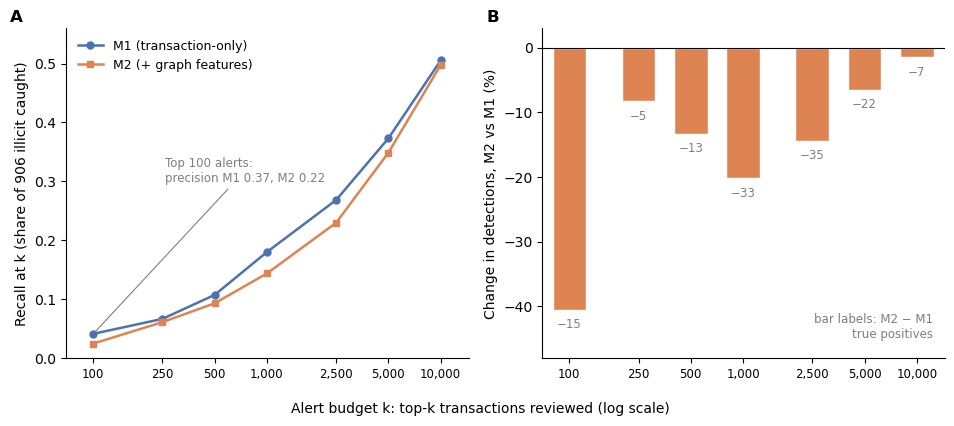

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, NullLocator

BLUE, ORANGE, DARK = "#4C72B0", "#DD8452", "#7F7F7F"   # same palette as Figure 1
N_ILLICIT = 906                                         # test-main illicit (locked)

ab = pd.read_csv(ROOT / "outputs" / "tables" / "12_alert_budget.csv")
m1 = ab[ab.model == "M1"].set_index("budget_k")
m2 = ab[ab.model == "M2"].set_index("budget_k")
k = m1.index.to_numpy()

# gates: the figure must agree with the verified Notebook 12 record (§4H)
assert len(ab) == 14 and (m1.index == m2.index).all()
assert (np.rint(ab.true_positives / ab.recall_at_k) == N_ILLICIT).all()
assert np.allclose(ab.precision_at_k, ab.true_positives / ab.budget_k)
diff = m2.true_positives - m1.true_positives
assert (diff == m2.m2_minus_m1_tp).all() and (diff < 0).all()
assert (m1.loc[100, "true_positives"], m2.loc[100, "true_positives"]) == (37, 22)
rel = 100 * diff / m1.true_positives
print(pd.DataFrame({"M1_TP": m1.true_positives, "M2_TP": m2.true_positives,
                    "diff": diff, "rel_%": rel.round(1)}))

fig, (axA, axB) = plt.subplots(1, 2, figsize=(9.6, 4.3))

# --- Panel A: share of all laundering caught at each queue size ----------
axA.plot(k, m1.recall_at_k, "o-", color=BLUE, lw=1.8, ms=5,
         label="M1 (transaction-only)")
axA.plot(k, m2.recall_at_k, "s-", color=ORANGE, lw=1.8, ms=5,
         label="M2 (+ graph features)")
axA.set_ylabel("Recall at k (share of 906 illicit caught)", fontsize=10)
axA.set_ylim(0, 0.56)
axA.legend(frameon=False, fontsize=9, loc="upper left")
axA.annotate("Top 100 alerts:\nprecision M1 0.37, M2 0.22",
             xy=(100, m1.loc[100, "recall_at_k"]), xytext=(260, 0.30),
             fontsize=8.5, color=DARK,
             arrowprops=dict(arrowstyle="-", lw=0.8, color=DARK))

# --- Panel B: M2's detections relative to M1 at the same budget ----------
# bars are k/1.25 to k*1.25 wide so they look symmetric on a log axis
axB.bar(k / 1.25, rel, width=k * (1.25 - 1 / 1.25), align="edge",
        color=ORANGE, edgecolor="white")
axB.axhline(0, color="black", lw=0.8)
for kk, r, d in zip(k, rel, diff):
    axB.text(kk, r - 1.2, f"{d:+d}".replace("-", "\u2212"), ha="center",
             va="top", fontsize=8.5, color=DARK)
axB.text(0.97, 0.06, "bar labels: M2 \u2212 M1\ntrue positives", transform=axB.transAxes,
         ha="right", fontsize=8.5, color=DARK)
axB.set_ylabel("Change in detections, M2 vs M1 (%)", fontsize=10)
axB.set_ylim(-48, 3)

# shared x-axis styling: real budget values as tick labels, no 10^n
for ax, tag in ((axA, "A"), (axB, "B")):
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(FixedLocator(k))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xticklabels([f"{v:,}" for v in k], fontsize=8.5)
    ax.set_xlim(70, 14500)
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(-0.14, 1.02, tag, transform=ax.transAxes, fontsize=12,
            fontweight="bold")

fig.supxlabel("Alert budget k: top-k transactions reviewed (log scale)",
              fontsize=10, y=0.02)
fig.tight_layout()
out = ROOT / "outputs" / "figures" / "13_alert_budget.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=300, bbox_inches="tight")
print("saved:", out)

saved: c:\Fintech-Project\graph_AML_pipeline\outputs\figures\13_case4_paired_waterfall.png


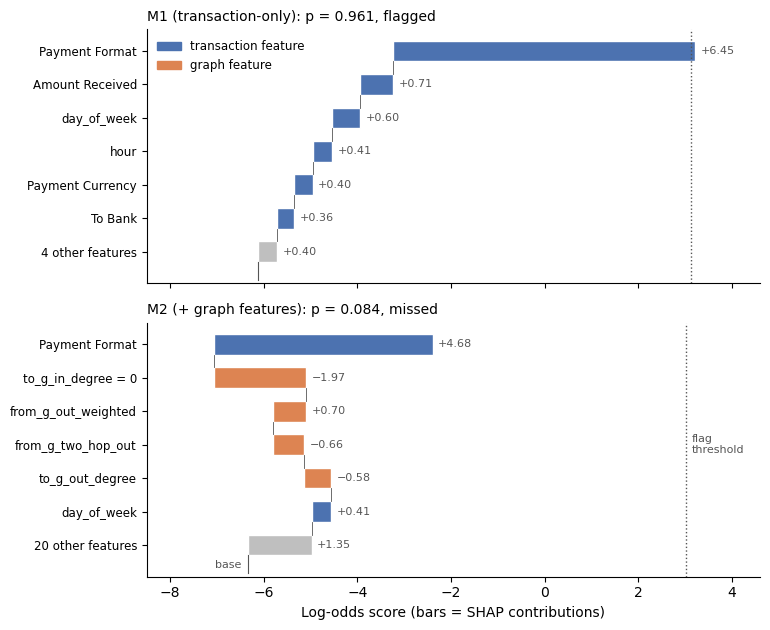

In [4]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

BLUE, ORANGE, GREY, DARK = "#4C72B0", "#DD8452", "#BFBFBF", "#555555"   # Figure 1 palette
CASE, N_SHOW = "4_m2_breaks_illicit", 6

cs = pd.read_csv(ROOT / "outputs" / "tables" / "09_case_shap_vectors.csv")
c4 = cs[cs["case"] == CASE]
thr = {"M1": json.loads((ROOT / "outputs" / "models" / "06_m1_threshold.json").read_text())["threshold"],
       "M2": json.loads((ROOT / "outputs" / "models" / "07_m2_threshold.json").read_text())["threshold"]}
logit = lambda p: np.log(p / (1 - p))
sigmoid = lambda z: 1 / (1 + np.exp(-z))

# gates: the figure must reproduce the verified Notebook 09 record (§4E)
assert c4["df_index"].unique().tolist() == [2313434]
assert (c4["model"] == "M1").sum() == 10 and (c4["model"] == "M2").sum() == 26
score = {m: g["base_value"].iloc[0] + g["shap"].sum() for m, g in c4.groupby("model")}
assert abs(sigmoid(score["M1"]) - 0.961138) < 5e-6 and abs(sigmoid(score["M2"]) - 0.083541) < 5e-6
indeg = c4[(c4["model"] == "M2") & (c4["feature"] == "to_g_in_degree")].iloc[0]
assert indeg["value"] == 0 and abs(indeg["shap"] - (-1.9716)) < 5e-5

def rows_for(g):
    """Top N_SHOW features by |SHAP|, plus one aggregated 'other' row."""
    g = g.assign(a=g["shap"].abs()).sort_values("a", ascending=False)
    top, rest = g.head(N_SHOW), g.iloc[N_SHOW:]
    labels = [f"{f} = 0" if (f == "to_g_in_degree" and v == 0) else f
              for f, v in zip(top["feature"], top["value"])]
    colours = [ORANGE if f.startswith(("from_g_", "to_g_")) else BLUE for f in top["feature"]]
    return (labels + [f"{len(rest)} other features"],
            list(top["shap"]) + [rest["shap"].sum()], colours + [GREY])

fig, axes = plt.subplots(2, 1, figsize=(7.8, 6.4), sharex=True)   # sharex = the x-scale fix
titles = {"M1": "M1 (transaction-only)", "M2": "M2 (+ graph features)"}

for ax, model in zip(axes, ["M1", "M2"]):
    g = c4[c4["model"] == model]
    base = g["base_value"].iloc[0]
    labels, vals, cols = rows_for(g)
    n = len(vals)
    ys = np.arange(n)[::-1]                    # largest at top, 'other' at bottom
    pos = base
    for y, v, col in zip(ys[::-1], vals[::-1], cols[::-1]):   # walk bottom -> top
        ax.barh(y, v, left=pos, height=0.62, color=col, edgecolor="white")
        end = pos + v
        ax.text(max(pos, end) + 0.12, y, f"{v:+.2f}".replace("-", "\u2212"),
                va="center", fontsize=8, color=DARK)
        if y < n - 1:                              # connector up to the next bar
            ax.plot([end, end], [y + 0.31, y + 0.69], color=DARK, lw=0.6)
        pos = end
    ax.plot([base, base], [-0.85, -0.31], color=DARK, lw=0.8)   # where the walk starts
    ax.axvline(logit(thr[model]), color=DARK, lw=1.0, ls=":")
    ax.set_yticks(ys)
    ax.set_yticklabels(labels, fontsize=8.5)
    ax.set_ylim(-0.95, n - 0.35)
    ax.spines[["top", "right"]].set_visible(False)
    verdict = "flagged" if sigmoid(pos) >= thr[model] else "missed"
    ax.set_title(f"{titles[model]}: p = {sigmoid(pos):.3f}, {verdict}",
                 fontsize=10, loc="left")

axes[1].text(logit(thr["M2"]) + 0.12, 3, "flag\nthreshold", fontsize=8, color=DARK, va="center")
axes[1].text(c4["base_value"].iloc[-1] - 0.15, -0.6, "base", fontsize=8, color=DARK, ha="right", va="center")
axes[1].set_xlim(-8.5, 4.6)
axes[1].set_xlabel("Log-odds score (bars = SHAP contributions)", fontsize=10)
axes[0].legend(handles=[Patch(color=BLUE, label="transaction feature"),
                        Patch(color=ORANGE, label="graph feature")],
               frameon=False, fontsize=8.5, loc="upper left")

fig.tight_layout()
out = ROOT / "outputs" / "figures" / "13_case4_paired_waterfall.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=300, bbox_inches="tight")
print("saved:", out)

saved: c:\Fintech-Project\graph_AML_pipeline\outputs\figures\13_recall_by_indegree.png


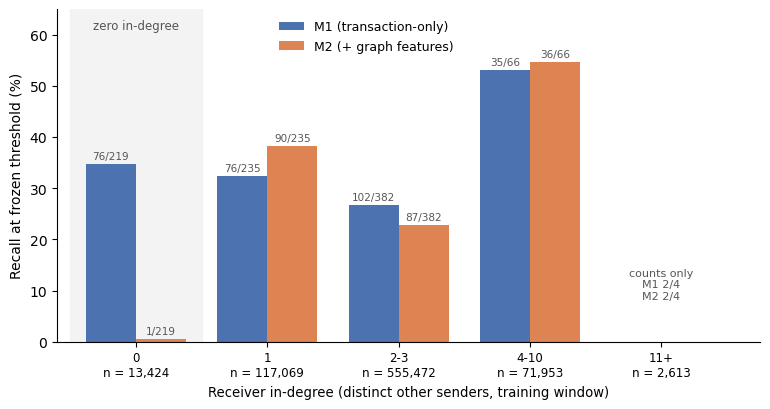

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, ORANGE, DARK = "#4C72B0", "#DD8452", "#555555"   # Figure 1 palette

bands = pd.read_csv(ROOT / "outputs" / "tables" / "09_indegree_bands.csv", dtype={"band": str})

# gates: the figure must reproduce the verified Notebook 09 record (§4E)
assert bands["band"].tolist() == ["0", "1", "2-3", "4-10", "11+"]
assert bands["illicit"].tolist() == [219, 235, 382, 66, 4]
assert bands["m1_tp"].tolist() == [76, 76, 102, 35, 2]
assert bands["m2_tp"].tolist() == [1, 90, 87, 36, 2]
assert (bands["status"] == "post-hoc, not registered").all()

# project degeneracy rule: < 1,000 rows or < 10 illicit -> counts only, no rate drawn
degenerate = (bands["n"] < 1000) | (bands["illicit"] < 10)
assert degenerate.tolist() == [False, False, False, False, True]

x = np.arange(len(bands))
w = 0.38
fig, ax = plt.subplots(figsize=(7.8, 4.2))

# shade the zero in-degree stratum: the segment Figure 2's case sits in
ax.axvspan(-0.5, 0.5, color="#F3F3F3", zorder=0)
ax.text(0, 61, "zero in-degree", ha="center", fontsize=8.5, color=DARK)

for offset, col, tp_col, rc_col, label in (
        (-w/2, BLUE, "m1_tp", "m1_recall_%", "M1 (transaction-only)"),
        (+w/2, ORANGE, "m2_tp", "m2_recall_%", "M2 (+ graph features)")):
    ok = ~degenerate
    ax.bar(x[ok] + offset, bands.loc[ok, rc_col], width=w, color=col, label=label)
    for xi, tp, ill, rc in zip(x[ok], bands.loc[ok, tp_col], bands.loc[ok, "illicit"], bands.loc[ok, rc_col]):
        ax.text(xi + offset, rc + 1.0, f"{tp}/{ill}", ha="center", fontsize=7.5, color=DARK)

# degenerate band: counts only, no bar
for xi in x[degenerate]:
    r = bands.iloc[xi]
    ax.text(xi, 8, f"counts only\nM1 {r.m1_tp}/{r.illicit}\nM2 {r.m2_tp}/{r.illicit}",
            ha="center", va="bottom", fontsize=8, color=DARK)

ax.set_xticks(x)
ax.set_xticklabels([f"{b}\nn = {n:,}" for b, n in zip(bands["band"], bands["n"])], fontsize=8.5)
ax.set_xlabel("Receiver in-degree (distinct other senders, training window)",
              fontsize=9.5)
ax.set_ylabel("Recall at frozen threshold (%)", fontsize=10)
ax.set_ylim(0, 65)
ax.set_xlim(-0.6, 4.75)
ax.legend(frameon=False, fontsize=9, loc="upper left", bbox_to_anchor=(0.30, 1.0))
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
out = ROOT / "outputs" / "figures" / "13_recall_by_indegree.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=300, bbox_inches="tight")
print("saved:", out)